In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

countries = ['ethiopia', 'kenya', 'sudan', 'tanzania', 'nigeria']
df_list = []

for country in countries:
    # Load the cleaned file from Task 2
    temp_df = pd.read_csv(f'../data/{country}_clean.csv')
    df_list.append(temp_df)

# Concatenate all into one big dataframe
master_df = pd.concat(df_list, ignore_index=True)

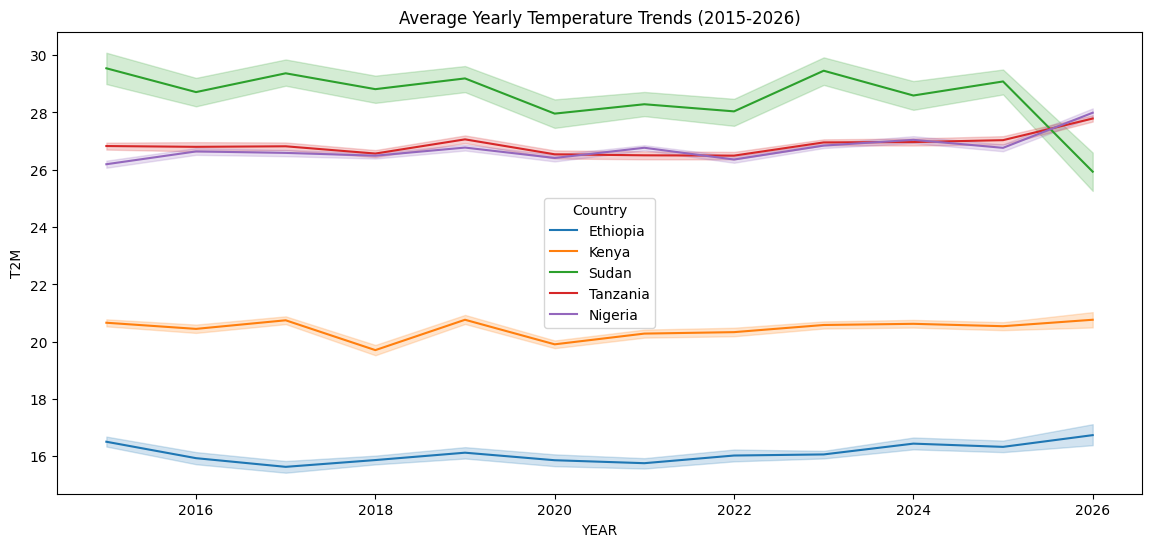

In [2]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=master_df, x='YEAR', y='T2M', hue='Country', estimator='mean')
plt.title('Average Yearly Temperature Trends (2015-2026)')
plt.show()

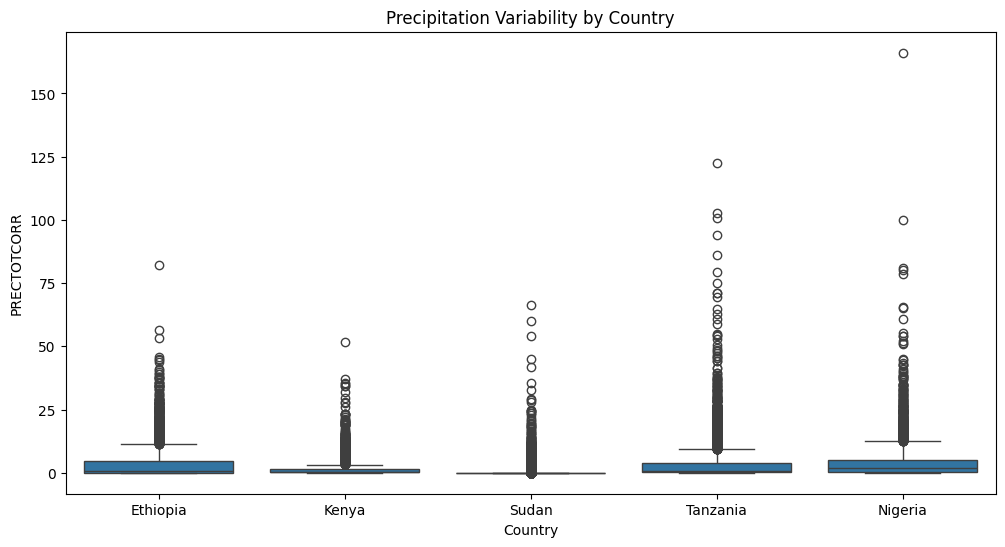

In [3]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=master_df, x='Country', y='PRECTOTCORR')
plt.title('Precipitation Variability by Country')
plt.show()

In [4]:
# Count days > 35°C per year per country
heat_days = master_df[master_df['T2M_MAX'] > 35].groupby(['Country', 'YEAR']).size().reset_index(name='Heat_Days')

In [5]:
def get_max_consecutive_dry(group):
    # Flag dry days (1) vs wet days (0)
    is_dry = (group['PRECTOTCORR'] < 1).astype(int)
    # Identify chunks of dry days
    condition = (is_dry == 0).cumsum()
    return is_dry.groupby(condition).sum().max()

dry_days = master_df.groupby(['Country', 'YEAR']).apply(get_max_consecutive_dry).reset_index(name='Max_Dry_Days')

In [7]:
# Filter out any groups that are too small just in case
data_groups = [master_df[master_df['Country'] == c]['T2M'].dropna() for c in countries]
data_groups = [g for g in data_groups if len(g) > 30] # Only keep groups with >30 data points

if len(data_groups) == len(countries):
    f_stat, p_val = f_oneway(*data_groups)
    print(f"ANOVA result: F={f_stat:.2f}, p={p_val:.4g}")
else:
    print("Not enough data to run ANOVA across all countries.")

Not enough data to run ANOVA across all countries.
